In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from plotnine import *
from datetime import datetime
import seaborn as sns

# modelling
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelBinarizer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestNeighbors

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.decomposition import PCA

#performance
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score, roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report
from sklearn.calibration import calibration_curve

from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch
from matplotlib import pyplot as plt

%matplotlib inline

In [6]:
# Import Dataset

shopping = pd.read_csv("shopping_trends_updated.csv")
shopping.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [10]:
#Data Preprocessing

#get a high level overview of the current state of the dataframe
shopping.info()

#check for missing values
print('\nMissing values per column:')
print(shopping.isnull().sum()) #no missing data found

#separate numerical and categorical features and hold them in list format
numericalCols = shopping.select_dtypes(include=np.number).columns.tolist()
categoricalCols = shopping.select_dtypes(exclude=np.number).columns.tolist()

#remove 'Customer ID' as it's not a feature for modeling
if 'Customer ID' in numericalCols:
    numericalCols.remove('Customer ID')

#apply one-hot encoding to categorical features
oneHot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) #initialize it
encodedFeatures = oneHot_encoder.fit_transform(shopping[categoricalCols])
encodedFeature_names = oneHot_encoder.get_feature_names_out(categoricalCols)
encoded_df = pd.DataFrame(encodedFeatures, columns=encodedFeature_names, index=shopping.index)

#add new one-hot encoded columns to the original numerical features to a single dataframe
processedShopping = pd.concat([shopping[numericalCols], encoded_df], axis=1)

#check for any rows with outliers
outlier_rows = pd.DataFrame(index=processedShopping.index)

#calculate IQR to determine outliers
for col in numericalCols:
    Q1 = processedShopping[col].quantile(0.25)
    Q3 = processedShopping[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #mark rows that are outliers for the current column
    outliers = (processedShopping[col] < lower_bound) | (processedShopping[col] > upper_bound)
    outlier_rows[col] = outliers

#count the number of outliers per column
print('Number of outliers per numerical column (using IQR method):')
print(outlier_rows.sum())

#display rows that have at least one outlier
print('\nRows with at least one outlier:')
display(processedShopping[outlier_rows.any(axis=1)]) #no outliers found

display(processedShopping.head()) #check to make sure everything looks okay

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,...,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly


,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,...,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,55,53,3.1,14,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,19,64,3.1,2,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,50,73,3.1,23,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,21,90,3.5,49,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,45,49,2.7,31,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


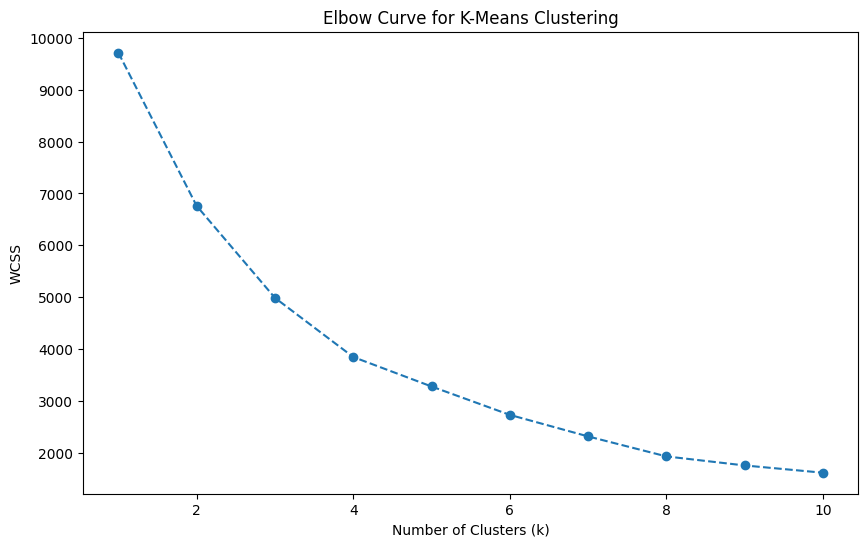

Silhouette Score: 0.29536946701498284
         Purchase Amount (USD)  Discount Applied_Yes  Discount Applied_No
cluster                                                                  
2                     0.870820              0.396859             0.603141
1                     0.860776              0.459621             0.540379
3                    -0.864685              0.464431             0.535569
0                    -0.881150              0.396660             0.603340


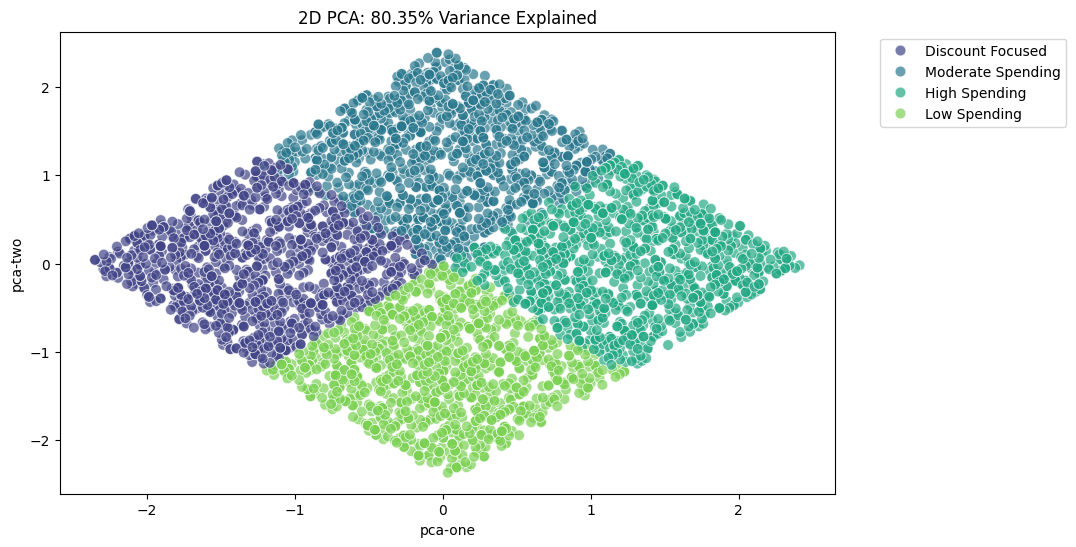

Standard Deviations After Scaling:
Purchase Amount (USD)    1.000128
Previous Purchases       1.000128
dtype: float64
WCSS: 3847.210160256645


In [8]:
#K-Means

#Selection of Variables
km_features = ['Purchase Amount (USD)', 'Previous Purchases']
km_df = processedShopping[km_features + ['Discount Applied_Yes']+['Discount Applied_No']].copy()

#Scaling larger variables
scaler = StandardScaler()
km_df[km_features] = scaler.fit_transform(km_df[km_features])

#Elbow Method to determine number of groups
wcss_km = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(km_df)
    wcss_km.append(kmeans.inertia_)

#Elbow Curve Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss_km, marker='o', linestyle='--')
plt.title('Elbow Curve for K-Means Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

#silhouette score to verify results
km_temp = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
labels = km_temp.fit_predict(km_df)
silhouette_avg = silhouette_score(km_df, labels)
print(f"Silhouette Score: {silhouette_avg}")

#K-Means with k=4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
km_df['cluster'] = kmeans.fit_predict(km_df)

#Assigning points to cluster
#Grouped by the mean spent USD for each cluster
clusters_avgs = km_df.groupby('cluster').agg({
    'Purchase Amount (USD)': 'mean',
    'Discount Applied_Yes': 'mean',
    'Discount Applied_No': 'mean'
}).sort_values(by='Purchase Amount (USD)', ascending = False)

#Cluster Labelling done dynamically, based on avg spending amount for each cluster
segment_labels_y = {
    clusters_avgs.index[0]: 'High Spending',
    clusters_avgs.index[1]: 'Moderate Spending',
    clusters_avgs.index[2]: 'Low Spending',
    clusters_avgs.index[3]: 'Discount Focused'

}
km_df['Customer_Segment'] = km_df['cluster'].map(segment_labels_y)
print(clusters_avgs)


#feature defining for PCA plot
pca_features = ['Purchase Amount (USD)', 'Previous Purchases',
                'Discount Applied_Yes', 'Discount Applied_No']

#PCA for a 2D visualization
pca_2d = PCA(n_components=2)
pca_2d_result = pca_2d.fit_transform(km_df[pca_features])

km_df['pca-one'] = pca_2d_result[:,0]
km_df['pca-two'] = pca_2d_result[:,1]

#plotting visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=km_df, x='pca-one', y='pca-two', hue='Customer_Segment',
    palette='viridis', s=60, alpha=0.7
)
#Variance for PCA plot
plt.title(f'2D PCA: {pca_2d.explained_variance_ratio_.sum():.2%} Variance Explained')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


#checking standard deviation
print("Standard Deviations After Scaling:")
print(km_df[km_features].std())

#WCSS measurement
print(f'WCSS: {kmeans.inertia_}')

Best Parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 23, 'weights': 'uniform'}
K-Nearest Neighbors Model Evaluation:
Accuracy: 0.7077
Precision: 0.6151
Recall: 0.8537
F1-Score: 0.7150
ROC AUC Score: 0.7740

Confusion Matrix:
[[266 179]
 [ 49 286]]


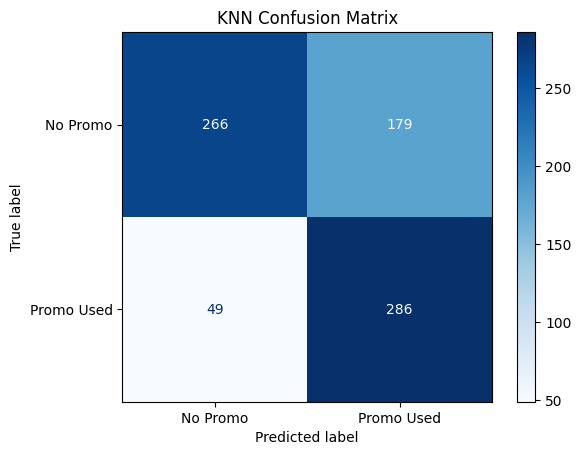

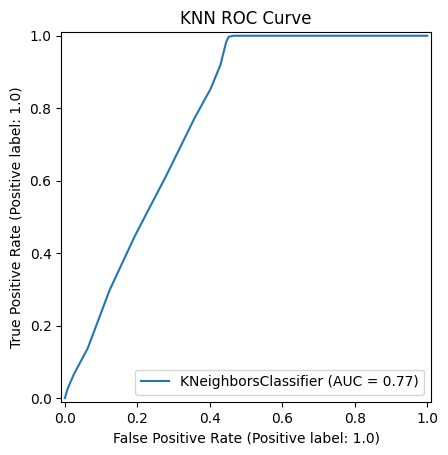

In [9]:
#KNN model

#establish the target variable
y = processedShopping['Promo Code Used_Yes']

#establish a list of the numerical columns to use
numericalFeatures = ['Age', 'Purchase Amount (USD)', 'Previous Purchases']

#establish a list of the original categorical columns to use
categorical = ['Gender', 'Category', 'Frequency of Purchases', 'Shipping Type', 'Season', 'Payment Method']
categoricalFeatures = [] #create an empty list to eventually hold all the one-hot encoded categorical columns
for name in categorical: #evaluate each original categorical column name that was specified earlier
    for col in processedShopping.columns: #iterate through each column in the preprocessed dataframe
        if col.startswith(name + '_'):
            categoricalFeatures.append(col) #add all one-hot encoded columns that start with the name to the list

#combine all requested feature columns, ensuring that the target vairable is not included in the features
features = [col for col in numericalFeatures + categoricalFeatures if col != 'Promo Code Used_Yes' and col != 'Promo Code Used_No']

#assign all those features as the model input
X = processedShopping[features]

#perform a 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

#z-score variables
scaler = StandardScaler()

#apply scalers to the numerical input values
X_train[numericalFeatures] = scaler.fit_transform(X_train[numericalFeatures])
X_test[numericalFeatures] = scaler.transform(X_test[numericalFeatures])

#initialize KNN model
knn = KNeighborsClassifier() #seed set for reproducibility

param_grid = {
    'n_neighbors': list(range(1, 31)), #test k from 1 to 30
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

#initialize a grid search to find the best hyperparameters
knn_grid = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc', refit = True)

knn_grid.fit(X_train, y_train) #fit the knn grid search to the training data

#print the best hyperparameters found
print(f"Best Parameters for KNN: {knn_grid.best_params_}")

#use the best model state to make predictions
best_knn = knn_grid.best_estimator_

yPred_knn = best_knn.predict(X_test) #get the model predictions
yProb_knn = best_knn.predict_proba(X_test)[:, 1] #get the probability of predicting a positive class

#model evaluation
print("K-Nearest Neighbors Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, yPred_knn):.4f}")
print(f"Precision: {precision_score(y_test, yPred_knn):.4f}")
print(f"Recall: {recall_score(y_test, yPred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, yPred_knn):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, yProb_knn):.4f}")

conf_matrix_knn = confusion_matrix(y_test, yPred_knn)
print("\nConfusion Matrix:")
print(conf_matrix_knn)

# Plot Confusion Matrix
disp_knn = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_knn, display_labels=['No Promo', 'Promo Used'])
disp_knn.plot(cmap=plt.cm.Blues)
plt.title('KNN Confusion Matrix')
plt.show()

# Plot ROC Curve
RocCurveDisplay.from_estimator(best_knn, X_test, y_test)
plt.title('KNN ROC Curve')
plt.show()


### Random Forest Classifier Model Training and Evaluation

In [11]:
#Random Forest Classifier model

#establish the target variable
y = processedShopping['Promo Code Used_Yes']

#establish a list of the numerical columns to use
numericalFeatures = ['Age', 'Purchase Amount (USD)', 'Previous Purchases']

#establish a list of the original categorical columns to use
categorical = ['Gender', 'Category', 'Frequency of Purchases', 'Shipping Type', 'Season', 'Payment Method']
categoricalFeatures = [] #create an empty list to eventually hold all the one-hot encoded categorical columns
for name in categorical: #evaluate each original categorical column name that was specified earlier
    for col in processedShopping.columns: #iterate through each column in the preprocessed dataframe
        if col.startswith(name + '_'):
            categoricalFeatures.append(col) #add all one-hot encoded columns that start with the name to the list

#combine all requested feature columns, ensuring that the target vairable is not included in the features
features = [col for col in numericalFeatures + categoricalFeatures if col != 'Promo Code Used_Yes' and col != 'Promo Code Used_No']

#assign all those features as the model input
X = processedShopping[features]

#perform a 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

#z-score variables
scaler = StandardScaler()

#apply scalers to the numerical input values
X_train[numericalFeatures] = scaler.fit_transform(X_train[numericalFeatures])
X_test[numericalFeatures] = scaler.transform(X_test[numericalFeatures])

Decision Tree Results
Accuracy: 0.6910
Precision: 0.6351
Recall: 0.6597
F1-Score: 0.6471

Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.71      0.73       445
         1.0       0.64      0.66      0.65       335

    accuracy                           0.69       780
   macro avg       0.69      0.69      0.69       780
weighted avg       0.69      0.69      0.69       780



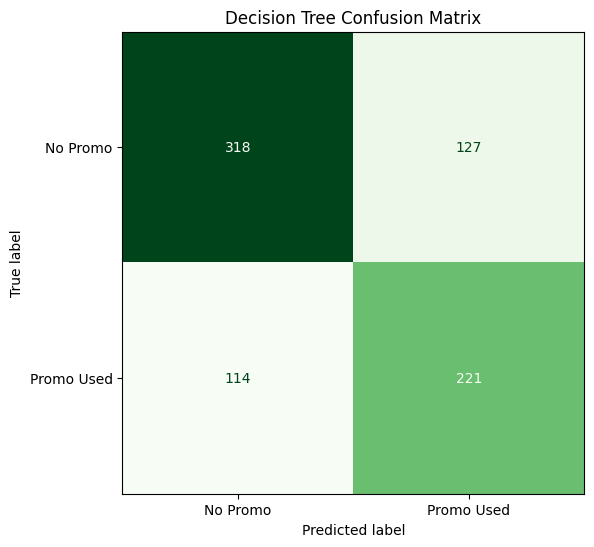

In [12]:
# Create Decision Tree model (baseline)
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = decision_tree_model.predict(X_test)

# Evaluate model
print("Decision Tree Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tree, pos_label=1):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tree, pos_label=1):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tree, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

# Create confusion matrix for Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Display confusion matrix
disp_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=['No Promo', 'Promo Used']
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6,6))

disp_tree.plot(
    cmap="Greens",
    ax=ax,
    colorbar=False
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

Random Forest Results
Accuracy: 0.7115
Precision: 0.6185
Recall: 0.8567
F1-Score: 0.7184

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.60      0.70       445
         1.0       0.62      0.86      0.72       335

    accuracy                           0.71       780
   macro avg       0.73      0.73      0.71       780
weighted avg       0.75      0.71      0.71       780



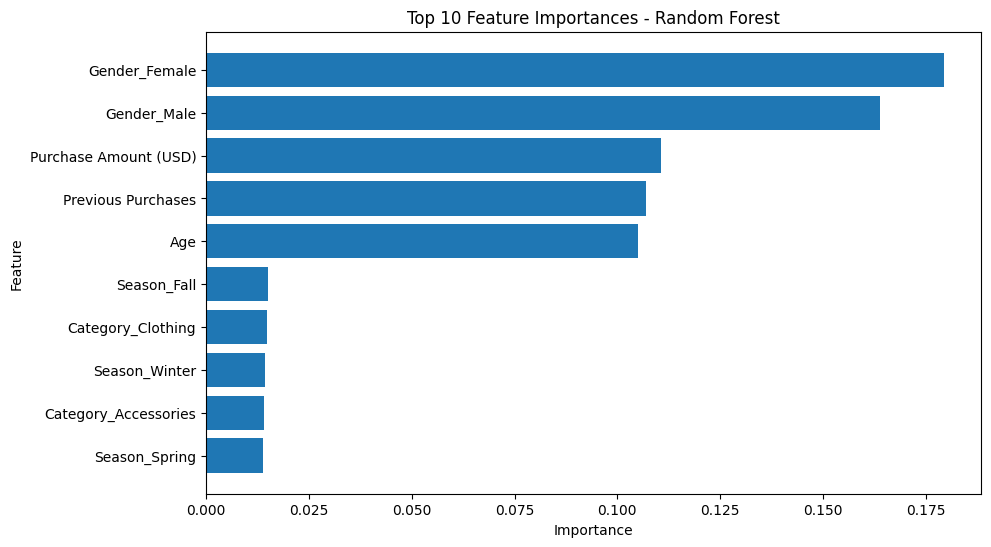

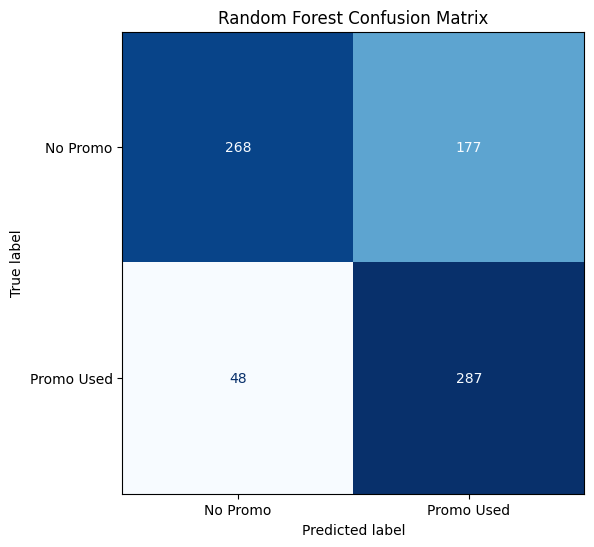

In [13]:
#Create Random Forest model
random_forest_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

# Train the Random Forest model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate model
print("Random Forest Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, pos_label=1):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, pos_label=1):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, pos_label=1):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Get feature importances
importances = random_forest_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X.columns, # Use X.columns for feature names
    "Importance": importances
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

# Plot feature importance
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")

plt.gca().invert_yaxis()

plt.show()

# Create confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['No Promo', 'Promo Used'] # Assuming 0=No Promo, 1=Promo Used
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6,6))

disp_rf.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [14]:
# Compare model performance
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf, pos_label=1),
        precision_score(y_test, y_pred_tree, pos_label=1)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf, pos_label=1),
        recall_score(y_test, y_pred_tree, pos_label=1)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rf, pos_label=1),
        f1_score(y_test, y_pred_tree, pos_label=1)
    ]
})

print("\nModel Comparison:")
display(comparison_df)


Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.711538,0.618534,0.856716,0.718398
1,Decision Tree,0.691026,0.635057,0.659701,0.647145
